# Introducción

Este proyecto se desarrolló inicialmente en el marco de la materia **Minería de Datos II** de la **Tecnicatura en Ciencia de Datos e Inteligencia Artificial (ISTEA)**, y fue posteriormente adaptado para integrar mi **portfolio profesional**. Su objetivo es implementar un **pipeline de datos** sobre una **arquitectura Big Data moderna**, utilizando **Apache Cassandra** (a través de **DataStax Astra**) como sistema de **almacenamiento distribuido**, y **PySpark** para el **procesamiento batch** de grandes volúmenes de información.

El caso se sitúa en un escenario realista: una **empresa fintech** que busca mejorar el **engagement** de nuevos usuarios en **Brasil** mediante una etapa de **onboarding guiado de 30 días**. Para analizar el comportamiento de estos usuarios y evaluar el impacto de la estrategia, se diseñó un flujo que permite **almacenar, limpiar y transformar datasets** de usuarios, transacciones y onboarding, dejándolos listos para su análisis.

La arquitectura adoptada sigue un enfoque **Data Lake zonificado**, que organiza los datos en capas progresivas —desde su forma cruda hasta su versión analítica— garantizando **escalabilidad**, **disponibilidad** y **tolerancia a fallos**.

# 1. Configuración inicial

In [1]:
# --- Librerías estándar  ---
import os
import sys

In [2]:
from etl_utils import (
    # --- Utilidades externas y librerías auxiliares ---
    load_dotenv, DataAPIClient, pd, np, plt,

    # --- Funciones de PySpark utilizadas en transformaciones ---
    col, to_date, to_timestamp, coalesce, sha2, lower, trim, split, concat, expr,
    regexp_replace, when, count, sum,

    # --- Funciones personalizadas desarrolladas en etl_utils.py ---
    hash_column,
    generalize_date_to_decade, generalize_date_to_range,
    mask_phone_number, mask_email,
    insertar_si_vacia_pandas,
    apply_universal_schema
)

In [3]:
# --- Tipos de datos de PySpark ---
# Se importan los tipos necesarios para definir esquemas de lectura en distintas capas (Landing, Universal, Smart)
from pyspark.sql.types import (
    StructType,
    StructField,
    StringType,
    IntegerType,
    LongType
)

In [4]:
# --- Conexión a Astra DB ---
# Se establece la conexión a la base de datos de DataStax Astra utilizando el token guardado en el archivo .env.
# Esto permite interactuar con las colecciones (crear, consultar, insertar datos, etc.) durante el pipeline ETL.
load_dotenv()
token = os.getenv("ASTRA_DB_TOKEN")

client = DataAPIClient(token)
db = client.get_database_by_api_endpoint(
    "https://d98a173a-af40-48d3-a917-c1a69442d83b-us-east-2.apps.astra.datastax.com",
    keyspace="data_users",
)

print(f"Connected to Astra DB: {db.list_collection_names()}")

Connected to Astra DB: ['cleansed_onboarding', 'cleansed_transactions', 'cleansed_users', 'raw_onboarding', 'raw_transactions', 'raw_users']


In [5]:
# --- Configuración del entorno PySpark ---
# Este bloque asegura que Spark use el mismo intérprete de Python del entorno actual
# y evita errores de comunicación (EOFException) en Windows.
import os, sys
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["PYTHONIOENCODING"] = "UTF-8"
os.environ["PYTHONUTF8"] = "1"

In [6]:
# Inicialización de Spark en modo local
# Forma estándar para entornos de desarrollo: evita dependencias de Hive/Hadoop y funciona igual en Windows, Mac y Linux
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Universal Zone")
    .config("spark.local.dir", r"C:\tmp\spark")  # Ruta temporal para Spark (necesaria en Windows)
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 3.5.1


# 1. Ingesta y Landing
En esta etapa se incorporan las fuentes de datos iniciales al sistema y se realiza la carga en la base de datos distribuida (Astra DB). Incluye tanto la ingesta de tablas crudas como su preparación mínima antes de la persistencia.

## 1.1 Ingesta
En esta etapa se cargan los datasets crudos en formato CSV desde el entorno local para su exploración inicial. Se verifica la estructura de las tablas y la presencia de valores faltantes o no válidos antes de avanzar a la fase de Landing.

In [7]:
# Carga de dataset 'users' desde la carpeta 'data'
users = pd.read_csv("data/dim_users.csv")

In [8]:
# Dataset users: se verifica presencia de NaN, inf o -inf por columna
problemas = users.isin([np.nan, np.inf, -np.inf])
columnas_con_problemas = problemas.any()
columnas_afectadas = columnas_con_problemas[columnas_con_problemas].index.tolist()

print("Columnas con NaN, inf o -inf:")
print(columnas_afectadas)

Columnas con NaN, inf o -inf:
['type', 'rubro']


In [9]:
# Carga de dataset 'transactions' desde la carpeta 'data'
transactions = pd.read_csv("data/fact_users_transactions.csv")

In [10]:
# Dataset transactions: se verifica presencia de NaN, inf o -inf por columna
problemas = transactions.isin([np.nan, np.inf, -np.inf])
columnas_con_problemas = problemas.any()
columnas_afectadas = columnas_con_problemas[columnas_con_problemas].index.tolist()

print("Columnas con NaN, inf o -inf:")
print(columnas_afectadas)

Columnas con NaN, inf o -inf:
['transaction_dt']


In [11]:
# Carga de dataset 'onboarding' desde la carpeta 'data'
onboarding = pd.read_csv("data/fact_users_onboarding.csv")

In [12]:
# # Dataset onboarding: se verifica presencia de NaN, inf o -inf por columna
problemas = onboarding.isin([np.nan, np.inf, -np.inf])
columnas_con_problemas = problemas.any()
columnas_afectadas = columnas_con_problemas[columnas_con_problemas].index.tolist()

print("Columnas con NaN, inf o -inf:")
print(columnas_afectadas)

Columnas con NaN, inf o -inf:
['Unnamed: 0', 'habito', 'habito_dt', 'activacion_dt', 'setup_dt', 'return_dt']


## 1.2 Landing  
En esta etapa se *persisten los datasets crudos en Astra DB* mediante la función `insertar_si_vacia_pandas()`.  
Esta función opera sobre **pandas DataFrames**, limpia los valores faltantes (reemplazando `NaN` por `None`), convierte el contenido a un formato JSON compatible y lo inserta en la base de datos.  

Si la colección no existe en Astra, la función la crea automáticamente. Luego, verifica si está vacía:  
- Si está vacía, inserta todos los registros.  
- Si ya contiene datos, no realiza ninguna inserción para evitar duplicaciones.  

Este procedimiento permite realizar una **carga inicial controlada** y asegurar que las futuras ejecuciones del pipeline no generen registros duplicados en las colecciones de Landing.

In [13]:
# Se inserta la tabla de usuarios en la colección 'raw_users' usando la función insertar_si_vacia()
insertar_si_vacia_pandas(users, "raw_users", db)

c:\Users\elias\OneDrive\Documentos\Repositorios_notebooks\ETL_Cassandra_Astra\etl_utils.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(


✅ Insertados 13000 registros en 'raw_users'.


In [14]:
# Se inserta la tabla de onboarding en 'raw_onboarding' usando insertar_si_vacia()
insertar_si_vacia_pandas(onboarding, "raw_onboarding", db)

c:\Users\elias\OneDrive\Documentos\Repositorios_notebooks\ETL_Cassandra_Astra\etl_utils.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(


✅ Insertados 13500 registros en 'raw_onboarding'.


In [15]:
# Se inserta la tabla de transacciones en 'raw_transactions' usando insertar_si_vacia()
insertar_si_vacia_pandas(transactions, "raw_transactions", db)

c:\Users\elias\OneDrive\Documentos\Repositorios_notebooks\ETL_Cassandra_Astra\etl_utils.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(


✅ Insertados 7675 registros en 'raw_transactions'.


# 2. Procesamiento Universal
En esta etapa se realiza la **extracción de los datos crudos almacenados en la zona Landing** (colecciones `raw_*` en Astra DB) y se inicializa la sesión de **Spark** para aplicar transformaciones posteriores.  

El objetivo principal de esta fase es disponer los datos en un entorno distribuido (Spark) que permita realizar limpiezas, conversiones de tipos y normalizaciones de forma eficiente, preparando así los datasets para su posterior almacenamiento en la capa Universal (cleansed).

## 2.1 Lectura desde capa Landing
En este apartado se realiza la lectura de los datos almacenados en la zona Landing (Astra DB), correspondientes a las colecciones raw_users, raw_onboarding y raw_transactions. Estos datasets serán convertidos a DataFrames de Spark para aplicar transformaciones posteriores en la etapa *Universal*.

In [16]:
# Conexión a la base de datos para traer la colección 'raw_users'
raw_users = db.get_collection("raw_users")
raw_users

Collection(name="raw_users", keyspace="data_users", database.api_endpoint="https://d98a173a-af40-48d3-a917-c1a69442d83b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:CJDJ...), ...))

In [17]:
# Conexión a la base de datos para traer la colección 'raw_transactions'
raw_transactions = db.get_collection("raw_transactions")
raw_transactions

Collection(name="raw_transactions", keyspace="data_users", database.api_endpoint="https://d98a173a-af40-48d3-a917-c1a69442d83b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:CJDJ...), ...))

In [18]:
# Conexión a la base de datos para traer la colección 'raw_onboarding'
raw_onboarding = db.get_collection("raw_onboarding")
raw_onboarding

Collection(name="raw_onboarding", keyspace="data_users", database.api_endpoint="https://d98a173a-af40-48d3-a917-c1a69442d83b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:CJDJ...), ...))

### 2.1.1 Tabla users_df  
Conversión de la colección *raw_users* en un DataFrame de Spark para su procesamiento en la etapa Universal.

**Definición del esquema para `users_df`**  
Se especifica el tipo de dato y la permisividad de valores nulos para cada campo.  
En *StructField*, el tercer parámetro (*nullable*) define si la columna permite valores nulos. Esta convención se aplica en todos los esquemas siguientes.

In [19]:
# 1. Definición del esquema en PySpark para el DataFrame 'users'
#    Lectura defensiva: todo como StringType; el casteo se hace en la limpieza.
schema_users = StructType([
    StructField("Unnamed: 0", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("name", StringType(), True),
    StructField("email", StringType(), True),
    StructField("address", StringType(), True),
    StructField("birth_dt", StringType(), True),
    StructField("phone", StringType(), True),
    StructField("type", StringType(), True),
    StructField("rubro", StringType(), True),
])

In [20]:
# 2. Extracción de datos desde Cassandra y construcción de registros como tuplas
#    Cada documento devuelto por raw_users.find() es un diccionario; 
#    se convierte en una tupla ordenada para ajustarse al esquema definido en Spark.
reg_users = [
    (
        str(doc.get("Unnamed: 0", "")),
        str(doc.get("user_id", "")),
        str(doc.get("name", "")),
        str(doc.get("email", "")),
        str(doc.get("address", "")),
        str(doc.get("birth_dt", "")),
        str(doc.get("phone", "")),
        str(doc.get("type", "")),
        str(doc.get("rubro", "")),
    )
    for doc in raw_users.find()
]

In [21]:
# 3. Creación del DataFrame en Spark a partir de la lista de tuplas y el esquema definido
users_df = spark.createDataFrame(reg_users, schema_users)

In [22]:
# 4. Se imprime el esquema del DataFrame de users_df
users_df.printSchema()

root
 |-- Unnamed: 0: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- address: string (nullable = true)
 |-- birth_dt: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- type: string (nullable = true)
 |-- rubro: string (nullable = true)



### 2.1.2 Tabla transactions_df  
Conversión de la colección *raw_transactions* en un DataFrame de Spark para su procesamiento en la etapa Universal.

**Definición del esquema para `transactions_df`**  
Se especifica el tipo de dato y la permisividad de valores nulos para cada campo.


In [23]:
# 1. Definición del esquema en PySpark para el DataFrame 'transactions'
#    Lectura defensiva: todos los campos como StringType para evitar errores de parseo.
#    Luego se castean a sus tipos finales (int, timestamp, etc.) en etapas posteriores.
schema_transactions = StructType([
    StructField("Unnamed: 0", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("transaction_dt", StringType(), True),
    StructField("type", StringType(), True),
    StructField("segment", StringType(), True)
])

In [24]:
# 2. Extracción de datos desde Cassandra y construcción de registros como tuplas
#    Cada documento devuelto por raw_transactions.find() es un diccionario.
#    Se convierte en una tupla de strings para coincidir con el esquema definido en Spark
#    y evitar errores de casteo en campos numéricos o vacíos.
reg_transactions = [
    (
        str(doc.get("Unnamed: 0") or ""),
        str(doc.get("user_id") or ""),
        str(doc.get("transaction_dt") or ""),
        str(doc.get("type") or ""),
        str(doc.get("segment") or "")
    )
    for doc in raw_transactions.find()
]

# Luego: drop("Unnamed: 0"); segment → int; transaction_dt → timestamp.

In [25]:
# 3. Creación del DataFrame en Spark a partir de la lista de tuplas y el esquema definido
transactions_df = spark.createDataFrame(reg_transactions, schema_transactions)
transactions_df

DataFrame[Unnamed: 0: string, user_id: string, transaction_dt: string, type: string, segment: string]

In [26]:
# 4. Se imprime el esquema del DataFrame de transactions_df
transactions_df.printSchema()

root
 |-- Unnamed: 0: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- transaction_dt: string (nullable = true)
 |-- type: string (nullable = true)
 |-- segment: string (nullable = true)



### 2.1.3 Tabla onboarding_df  
Conversión de la colección *raw_onboarding* en un DataFrame de Spark para su procesamiento en la etapa Universal.

**Definición del esquema para `onboarding_df`**  
Se especifica el tipo de dato y la permisividad de valores nulos para cada campo.

In [27]:
# 1. Definición del esquema en PySpark para el DataFrame 'onboarding'
#    Lectura defensiva: todos los campos como StringType para evitar errores de parseo/serialización.
#    Luego se castean a sus tipos finales (fecha, boolean, double, etc.) en una etapa posterior.
schema_onboarding = StructType([
    StructField("Unnamed: 0", StringType(), True),
    StructField("first_login_dt", StringType(), True),
    StructField("week_year", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("habito", StringType(), True),
    StructField("habito_dt", StringType(), True),
    StructField("activacion", StringType(), True),
    StructField("activacion_dt", StringType(), True),
    StructField("setup", StringType(), True),
    StructField("setup_dt", StringType(), True),
    StructField("return", StringType(), True),
    StructField("return_dt", StringType(), True)
])

In [28]:
# 2. Extracción de datos desde Cassandra y construcción de registros como tuplas
#    Cada documento devuelto por raw_onboarding.find() es un diccionario;
#    se convierte en una tupla ordenada para ajustarse al esquema definido en Spark.
reg_onboarding = [
    (
        str(doc.get("Unnamed: 0") or ""),
        str(doc.get("first_login_dt") or ""),
        str(doc.get("week_year") or ""),
        str(doc.get("user_id") or ""),
        str(doc.get("habito") or ""),
        str(doc.get("habito_dt") or ""),
        str(doc.get("activacion") or ""),
        str(doc.get("activacion_dt") or ""),
        str(doc.get("setup") or ""),
        str(doc.get("setup_dt") or ""),
        str(doc.get("return") or ""),
        str(doc.get("return_dt") or "")
    )
    for doc in raw_onboarding.find()
]

In [29]:
# 3. Creación del DataFrame en Spark a partir de la lista de tuplas y el esquema definido
onboarding_df = spark.createDataFrame(reg_onboarding, schema_onboarding)

In [30]:
# 4. Se imprime el esquema del DataFrame 'onboarding'
onboarding_df.printSchema()

root
 |-- Unnamed: 0: string (nullable = true)
 |-- first_login_dt: string (nullable = true)
 |-- week_year: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: string (nullable = true)
 |-- habito_dt: string (nullable = true)
 |-- activacion: string (nullable = true)
 |-- activacion_dt: string (nullable = true)
 |-- setup: string (nullable = true)
 |-- setup_dt: string (nullable = true)
 |-- return: string (nullable = true)
 |-- return_dt: string (nullable = true)



## 2.2 Limpieza previa

En esta etapa se realiza una **limpieza básica de los datos crudos**, preparando los DataFrames para su posterior persistencia en la capa *Universal*.  
Las tareas incluyen:

- Eliminación de columnas innecesarias o índices heredados.  
- Conversión de tipos (por ejemplo: fechas, booleanos, valores numéricos).  
- Normalización de formatos y valores faltantes.  
- Estandarización de los nombres de columnas cuando sea necesario.  
- Anonimización u ofuscación de datos sensibles (por ejemplo: IDs, emails, información personal).

Este paso permite contar con datasets coherentes, tipados correctamente y libres de información sensible, listos para su almacenamiento en Cassandra en la capa *Universal*.

### 2.2.1 Limpieza user_df

In [31]:
# Se crea una copia base del DataFrame original para aplicar las transformaciones de limpieza
cleansed_users_df = users_df

In [32]:
# Eliminación de índice heredado del CSV
# Esta columna fue generada automáticamente al exportar el CSV con índice.
# No representa una variable real del negocio y se descarta en la capa Universal.
cleansed_users_df = cleansed_users_df.drop("Unnamed: 0")

In [33]:
# Chequeo de tipos antes de aplicar transformaciones
cleansed_users_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- address: string (nullable = true)
 |-- birth_dt: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- type: string (nullable = true)
 |-- rubro: string (nullable = true)



In [34]:
# Conversión de tipo para la columna 'rubro'
# Se transforma a IntegerType para permitir su uso en segmentaciones, agrupamientos y análisis numéricos.
# Al ser un identificador de rubro de negocio, su tratamiento como entero mejora la eficiencia en Spark.
cleansed_users_df = cleansed_users_df.withColumn("rubro", col("rubro").cast(IntegerType()))

In [35]:
# Conversión de 'birth_dt' a tipo DateType
# Permite realizar operaciones temporales precisas (por ej. cálculo de edad, segmentación por rangos etarios, comparaciones con fechas de login).
cleansed_users_df = cleansed_users_df.withColumn("birth_dt", to_date("birth_dt", "yyyy-MM-dd"))

In [36]:
# Limpieza de 'phone': eliminación de caracteres no numéricos y conversión de vacíos a NULL
cleansed_users_df = cleansed_users_df.withColumn(
    "phone",
    when(regexp_replace(col("phone"), "[^0-9]", "") != "", 
         regexp_replace(col("phone"), "[^0-9]", ""))
    .otherwise(None)
)

In [37]:
# Conversión a LongType para admitir números telefónicos extensos
cleansed_users_df = cleansed_users_df.withColumn("phone", col("phone").cast(LongType()))

In [38]:
# Verificación de prefijo 'MLB' en user_id
# El proyecto se centra exclusivamente en usuarios de Brasil, cuyo identificador comienza con 'MLB'.
# Este control asegura que no haya registros fuera del país objetivo.

# Cantidad total de usuarios en el dataset
print(f"Cantidad total de usuarios en el dataset: {cleansed_users_df.count()}")

# Filtrado de usuarios cuyo identificador comienza con 'MLB' (Brasil)
dim_users_filtrado = cleansed_users_df.filter(col("user_id").startswith("MLB"))

# Cantidad de usuarios válidos (de Brasil)
print(f"Cantidad de usuarios válidos (user_id comienza con 'MLB'): {dim_users_filtrado.count()}")

Cantidad total de usuarios en el dataset: 13000
Cantidad de usuarios válidos (user_id comienza con 'MLB'): 13000


In [39]:
# Verificación de valores nulos: no se detectan registros con campos vacíos o nulos
cleansed_users_df.select([
    sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)).alias(c)
    for c in cleansed_users_df.columns
]).show()

+-------+----+-----+-------+--------+-----+----+-----+
|user_id|name|email|address|birth_dt|phone|type|rubro|
+-------+----+-----+-------+--------+-----+----+-----+
|      0|   0|    0|      0|       0|    0|   0|11000|
+-------+----+-----+-------+--------+-----+----+-----+



In [40]:
# Verificación de valores duplicados: se controla duplicación por user_id
cleansed_users_df.groupBy("user_id").agg(count("*").alias("cantidad")).filter("cantidad > 1").show()

+-------+--------+
|user_id|cantidad|
+-------+--------+
+-------+--------+



In [41]:
# Verificación final del esquema tras la limpieza
# Confirma que todas las columnas tengan el tipo correcto antes de la persistencia
cleansed_users_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- address: string (nullable = true)
 |-- birth_dt: date (nullable = true)
 |-- phone: long (nullable = true)
 |-- type: string (nullable = true)
 |-- rubro: integer (nullable = true)



### 2.2.2 Limpieza  'transactions_df'

In [42]:
# Se crea una copia base del DataFrame original para aplicar las transformaciones de limpieza
cleansed_transactions_df = transactions_df

In [43]:
# Eliminación de índice heredado del CSV
# Esta columna fue generada automáticamente al exportar el CSV con índice.
# No representa una variable real del negocio y se descarta en la capa Universal.
cleansed_transactions_df = cleansed_transactions_df.drop("Unnamed: 0")

In [44]:
# Chequeo de tipos antes de aplicar transformaciones
cleansed_transactions_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- transaction_dt: string (nullable = true)
 |-- type: string (nullable = true)
 |-- segment: string (nullable = true)



In [45]:
# Conversión de 'transaction_dt' a tipo TimestampType
# Se parsea el string con formato completo (fecha + hora + fracciones de segundo),
# conservando toda la precisión temporal. Esto permite detectar duplicados reales
# únicamente cuando todos los campos coinciden (incluyendo hora, minutos y segundos),
# reduciendo falsos positivos que ocurrirían si se truncara a fecha.
cleansed_transactions_df = cleansed_transactions_df.withColumn(
    "transaction_dt",
    to_timestamp("transaction_dt", "yyyy-MM-dd HH:mm:ss.SSSSSSSSS")
)

# Verificación rápida de la conversión a TimestampType
cleansed_transactions_df.select("transaction_dt").show(5, truncate=False)

+--------------------------+
|transaction_dt            |
+--------------------------+
|2022-01-02 23:32:33.942369|
|2022-01-26 17:35:55.193173|
|2022-02-03 03:38:45.236408|
|2022-01-19 08:34:26.876807|
|2022-01-19 22:43:03.596009|
+--------------------------+
only showing top 5 rows



In [46]:
# Revisión de valores únicos antes del casteo numérico
# Esto permite detectar espacios, vacíos u otros valores no válidos.
cleansed_transactions_df.select("type").distinct().orderBy("type").show(truncate=False)
cleansed_transactions_df.select("segment").distinct().orderBy("segment").show(truncate=False)

+----+
|type|
+----+
|1   |
|2   |
|3   |
|4   |
|5   |
|6   |
|7   |
|8   |
|9   |
+----+

+-------+
|segment|
+-------+
|1      |
|2      |
+-------+



In [47]:
# Casteo de 'type' a IntegerType
cleansed_transactions_df = cleansed_transactions_df.withColumn("type", col("type").cast(IntegerType()))

# Casteo de 'segment' a IntegerType
cleansed_transactions_df = cleansed_transactions_df.withColumn("segment", col("segment").cast(IntegerType()))

In [48]:
# Verificación de valores nulos por columna
for c in cleansed_transactions_df.columns:
    try:
        nulos = cleansed_transactions_df.filter(col(c).isNull()).count()
        print(f"{c}: {nulos} valores nulos")
    except Exception as e:
        print(f"Error en columna '{c}': {e}")

user_id: 0 valores nulos
transaction_dt: 20 valores nulos
type: 0 valores nulos
segment: 0 valores nulos


In [49]:
# Eliminación de registros con 'transaction_dt' nulo
# Se descartan registros sin fecha de transacción para asegurar consistencia temporal.
registros_nulos = cleansed_transactions_df.filter(col("transaction_dt").isNull()).count()
print(f"Registros eliminados por 'transaction_dt' nulo: {registros_nulos}")

cleansed_transactions_df = cleansed_transactions_df.filter(col("transaction_dt").isNotNull())

Registros eliminados por 'transaction_dt' nulo: 20


In [50]:
# Verificación posterior: deben quedar 0 valores nulos en 'transaction_dt'
print("Nulos restantes en 'transaction_dt':", cleansed_transactions_df.filter(col("transaction_dt").isNull()).count())

Nulos restantes en 'transaction_dt': 0


In [51]:
# Verificación de duplicados exactos
# Se agrupan todas las columnas para detectar filas idénticas (incluye timestamp completo).
duplicados = (
    cleansed_transactions_df
    .groupBy(*cleansed_transactions_df.columns)  # el asterisco es más limpio que pasar la lista completa
    .count()
    .filter(col("count") > 1)
)

In [52]:
print(f"Duplicados detectados: {duplicados.count()}")

Duplicados detectados: 1787


In [53]:
# Eliminación de duplicados conservando la primera ocurrencia
cleansed_transactions_df = cleansed_transactions_df.dropDuplicates(cleansed_transactions_df.columns)

In [54]:
# Verificación posterior a la eliminación: debe dar 0
verif_post = (
    cleansed_transactions_df
    .groupBy(cleansed_transactions_df.columns)
    .count()
    .filter(col("count") > 1)
)
print(f"Duplicados restantes tras la limpieza: {verif_post.count()}")

Duplicados restantes tras la limpieza: 0


In [55]:
# Conversión final de 'transaction_dt' a tipo DateType
# Una vez eliminados los duplicados con precisión de timestamp, se trunca la columna
# a fecha (año-mes-día) para simplificar el almacenamiento y los análisis diarios.
cleansed_transactions_df = cleansed_transactions_df.withColumn(
    "transaction_dt",
    to_date(col("transaction_dt"))
)

# Verificación rápida de la conversión a tipo DateType
cleansed_transactions_df.select("transaction_dt").show(5, truncate=False)

+--------------+
|transaction_dt|
+--------------+
|2022-01-13    |
|2022-01-20    |
|2022-01-20    |
|2022-01-08    |
|2022-01-16    |
+--------------+
only showing top 5 rows



In [56]:
# Verificación final del esquema tras la limpieza
# Confirma que todas las columnas tengan el tipo correcto antes de la persistencia
cleansed_transactions_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- transaction_dt: date (nullable = true)
 |-- type: integer (nullable = true)
 |-- segment: integer (nullable = true)



### 2.2.3 Limpieza 'onboarding_df'

In [57]:
cleansed_onboarding_df = onboarding_df

In [58]:
# Eliminación de índice heredado del CSV
# Esta columna fue generada automáticamente al exportar el CSV con índice.
# No representa una variable real del negocio y se descarta en la capa Universal.
cleansed_onboarding_df = cleansed_onboarding_df.drop("Unnamed: 0")

In [59]:
# Chequeo de tipos antes de aplicar transformaciones
cleansed_onboarding_df.printSchema()

root
 |-- first_login_dt: string (nullable = true)
 |-- week_year: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: string (nullable = true)
 |-- habito_dt: string (nullable = true)
 |-- activacion: string (nullable = true)
 |-- activacion_dt: string (nullable = true)
 |-- setup: string (nullable = true)
 |-- setup_dt: string (nullable = true)
 |-- return: string (nullable = true)
 |-- return_dt: string (nullable = true)



In [60]:
# Normalización de valores vacíos en columnas binarias
# En las columnas 'habito', 'activacion', 'setup' y 'return', los valores vacíos ("")
# indican la ausencia del atributo. Antes de convertir a enteros, se reemplazan estas
# cadenas vacías por "0" para evitar errores de casteo y asegurar consistencia.
cleansed_onboarding_df = (
    cleansed_onboarding_df
    .withColumn("habito", when(trim(col("habito")) == "", "0").otherwise(col("habito")))
    .withColumn("activacion", when(trim(col("activacion")) == "", "0").otherwise(col("activacion")))
    .withColumn("setup", when(trim(col("setup")) == "", "0").otherwise(col("setup")))
    .withColumn("return", when(trim(col("return")) == "", "0").otherwise(col("return")))
)

In [61]:
# Conversión de columnas a IntegerType
# Una vez reemplazados los valores vacíos, se procede a convertir las columnas a entero.
# Esto permite realizar operaciones numéricas (conteos, promedios, agrupamientos) sin errores de formato.
cleansed_onboarding_df = (
    cleansed_onboarding_df
    .withColumn("habito", col("habito").cast("int"))
    .withColumn("week_year", col("week_year").cast("int"))   # no tenía vacíos, se castea directo
    .withColumn("activacion", col("activacion").cast("int"))
    .withColumn("setup", col("setup").cast("int"))
    .withColumn("return", col("return").cast("int"))
)

In [62]:
# Conversión de 'week_year' a IntegerType
# Esta columna representa la semana del año en que ocurrió el primer login.
# Se castea a entero para permitir ordenamientos y agrupamientos cronológicos precisos.
cleansed_onboarding_df = cleansed_onboarding_df.withColumn("week_year", col("week_year").cast("int"))

In [63]:
# Conversión flexible de columnas de fecha a tipo TimestampType
# Se utiliza coalesce() para probar distintos formatos de fecha y hora, 
# seleccionando el primer parseo válido encontrado para cada registro.
# En esta etapa se conserva la precisión completa (fecha + hora + segundos),
# lo que permite detectar duplicados reales antes de truncar a fecha simple.
for c in ["first_login_dt", "habito_dt", "activacion_dt", "setup_dt", "return_dt"]:
    cleansed_onboarding_df = cleansed_onboarding_df.withColumn(
        c,
        coalesce(
            to_timestamp(col(c), "yyyy-MM-dd HH:mm:ss.SSSSSSSSS"),
            to_timestamp(col(c), "yyyy-MM-dd HH:mm:ss"),
            to_timestamp(col(c), "yyyy-MM-dd'T'HH:mm:ss.SSSX"),
            to_timestamp(col(c), "yyyy-MM-dd'T'HH:mm:ssX"),
            to_timestamp(col(c), "yyyy-MM-dd")
        )
    )

In [64]:
# Se verifica visualmente la correcta transformación a tipo date de las columnas apuntadas.
# Las columnas de fecha contienen valores NULL cuando el evento asociado (como activación, retorno o hábito) no ocurrió.
# Esta ausencia es esperable y refleja el comportamiento real de los usuarios.
cleansed_onboarding_df.select(
    "first_login_dt",
    "habito_dt",
    "activacion_dt",
    "setup_dt",
    "return_dt"
).show(10, truncate=False)

+-------------------+---------+-------------------+-------------------+-------------------+
|first_login_dt     |habito_dt|activacion_dt      |setup_dt           |return_dt          |
+-------------------+---------+-------------------+-------------------+-------------------+
|2022-01-17 00:00:00|NULL     |NULL               |NULL               |2022-01-19 00:00:00|
|2022-01-05 00:00:00|NULL     |2022-01-06 00:00:00|2022-01-05 00:00:00|2022-01-06 00:00:00|
|2022-01-06 00:00:00|NULL     |NULL               |2022-01-19 00:00:00|2022-01-12 00:00:00|
|2022-01-13 00:00:00|NULL     |NULL               |NULL               |NULL               |
|2022-01-25 00:00:00|NULL     |NULL               |NULL               |2022-02-10 00:00:00|
|2022-01-07 00:00:00|NULL     |2022-01-07 00:00:00|2022-01-08 00:00:00|2022-01-08 00:00:00|
|2022-01-08 00:00:00|NULL     |2022-01-08 00:00:00|NULL               |2022-01-12 00:00:00|
|2022-01-26 00:00:00|NULL     |NULL               |NULL               |NULL     

In [65]:
# Verificación final del esquema del DataFrame de onboarding
cleansed_onboarding_df.printSchema()

root
 |-- first_login_dt: timestamp (nullable = true)
 |-- week_year: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: integer (nullable = true)
 |-- habito_dt: timestamp (nullable = true)
 |-- activacion: integer (nullable = true)
 |-- activacion_dt: timestamp (nullable = true)
 |-- setup: integer (nullable = true)
 |-- setup_dt: timestamp (nullable = true)
 |-- return: integer (nullable = true)
 |-- return_dt: timestamp (nullable = true)



In [66]:
# Verificación de duplicados exactos en onboarding_df
# Se agrupan todas las columnas para detectar filas idénticas (incluye timestamp completo en fechas).
# Esto permite identificar registros repetidos antes de truncar las fechas o persistir los datos.
duplicados_onboarding = (
    cleansed_onboarding_df
    .groupBy(*cleansed_onboarding_df.columns)
    .count()
    .filter(col("count") > 1)
)

In [67]:
print(f"Duplicados detectados en onboarding_df: {duplicados_onboarding.count()}")

Duplicados detectados en onboarding_df: 500


In [68]:
# Eliminación de registros duplicados exactos
# Tras estandarizar las fechas, algunas filas se vuelven idénticas en todas sus columnas,
# por lo que se conservan como una sola.
cleansed_onboarding_df = cleansed_onboarding_df.dropDuplicates(cleansed_onboarding_df.columns)

In [69]:
# Verificación posterior: no deberían existir duplicados exactos restantes
verif_post_onboarding = (
    cleansed_onboarding_df
    .groupBy(*cleansed_onboarding_df.columns)
    .count()
    .filter(col("count") > 1)
)
print(f"Duplicados restantes tras la limpieza: {verif_post_onboarding.count()}")

Duplicados restantes tras la limpieza: 0


In [70]:
# Conversión final de columnas de fecha a tipo DateType
# Una vez detectados y eliminados los duplicados con precisión de timestamp,
# se truncan las columnas a fecha (año-mes-día) para simplificar el almacenamiento
# y facilitar los análisis diarios posteriores.
for c in ["first_login_dt", "habito_dt", "activacion_dt", "setup_dt", "return_dt"]:
    cleansed_onboarding_df = cleansed_onboarding_df.withColumn(c, to_date(col(c)))

In [71]:
# Verificación rápida de la conversión a DateType
cleansed_onboarding_df.select(
    "first_login_dt", "habito_dt", "activacion_dt", "setup_dt", "return_dt"
).show(5, truncate=False)

+--------------+----------+-------------+----------+----------+
|first_login_dt|habito_dt |activacion_dt|setup_dt  |return_dt |
+--------------+----------+-------------+----------+----------+
|2022-01-10    |2022-02-05|2022-01-10   |2022-02-02|2022-01-29|
|2022-01-31    |2022-02-04|2022-01-31   |2022-01-31|2022-02-01|
|2022-01-21    |2022-02-06|2022-01-24   |2022-01-21|2022-01-22|
|2022-01-02    |2022-01-16|2022-01-04   |2022-01-03|2022-01-03|
|2022-01-03    |2022-01-15|2022-01-10   |2022-01-10|2022-01-05|
+--------------+----------+-------------+----------+----------+
only showing top 5 rows



**Verificamos ahora inconsistencias lógicas según la consigna**

*Reglas de negocio esperadas:*

-Si hábito = 1, entonces debería haber activacion = 1

-Si setup = 1, debería existir setup_dt

-Si return = 1, debería haber return_dt

In [72]:
# Inconsistencia 1: habito = 1 pero activacion = 0
inconsistencia1 = cleansed_onboarding_df.filter((col("habito") == 1) & (col("activacion") == 0))

print(f"Cantidad de inconsistencias (habito=1 y activacion=0): {inconsistencia1.count()}")

# Se muestran las inconsistencias (habito=1 y activacion=0) en las columnas relevantes
inconsistencia1.select("habito", "activacion").show(5, truncate=False)

Cantidad de inconsistencias (habito=1 y activacion=0): 4
+------+----------+
|habito|activacion|
+------+----------+
|1     |0         |
|1     |0         |
|1     |0         |
|1     |0         |
+------+----------+



In [73]:
# Eliminación de inconsistencias: habito = 1 y activacion = 0
# No es consistente que un usuario haya llegado al hábito sin activación,
# por lo que se eliminan estas filas para mantener coherencia con la lógica de negocio.
cleansed_onboarding_df = cleansed_onboarding_df.filter(~((col("habito") == 1) & (col("activacion") == 0)))

In [74]:
# Verificación posterior: no deberían quedar registros con esta inconsistencia
cleansed_onboarding_df.filter(
    (col("habito") == 1) & (col("activacion") == 0)
).select("habito", "activacion").show()

+------+----------+
|habito|activacion|
+------+----------+
+------+----------+



In [75]:
# Este código devuelve 0, por lo cual la limpieza fue exitosa.
print("Cantidad de incosistencias de hábito sin activación:", cleansed_onboarding_df.filter((col("habito") == 1) & (col("activacion") == 0)).count())

Cantidad de incosistencias de hábito sin activación: 0


In [76]:
# Verificación final del esquema tras la limpieza
# Confirma que todas las columnas tengan el tipo correcto antes de la persistencia
cleansed_onboarding_df.printSchema()

root
 |-- first_login_dt: date (nullable = true)
 |-- week_year: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- habito: integer (nullable = true)
 |-- habito_dt: date (nullable = true)
 |-- activacion: integer (nullable = true)
 |-- activacion_dt: date (nullable = true)
 |-- setup: integer (nullable = true)
 |-- setup_dt: date (nullable = true)
 |-- return: integer (nullable = true)
 |-- return_dt: date (nullable = true)



## 2.3 Anonimización de datos

En esta etapa se aplican técnicas de anonimización sobre los datasets previamente limpiados, con el objetivo de proteger información sensible antes de su publicación en un repositorio público.
Se utilizan distintas estrategias según el tipo de dato:
- **Hashing**: se aplica a *user_id* para anonimizar completamente los identificadores, manteniendo su unicidad para futuros análisis y joins.  
- **Generalización**: se utiliza sobre atributos temporales (por ejemplo, *birth_date*) para agruparlos por períodos (década, lustro), reduciendo granularidad.  
- **Enmascaramiento parcial**: se aplica a variables de contacto (teléfono, email), conservando únicamente partes no sensibles (código de área o dominio de correo).

Estas transformaciones permiten que los datos mantengan su valor analítico, al tiempo que se resguarda la identidad de los usuarios.

#### 2.3.1 Hashing

In [77]:
# Anonimización de 'user_id' mediante hashing (SHA-256)
# --------------------------------------------------
# Se aplica la misma función de hashing a los tres DataFrames para asegurar
# consistencia en joins y análisis posteriores, manteniendo la privacidad de los usuarios.

# Users
cleansed_users_df = cleansed_users_df.withColumn(
    "user_id_hashed",
    sha2(lower(trim(col("user_id"))), 256)
)

# Transactions
cleansed_transactions_df = cleansed_transactions_df.withColumn(
    "user_id_hashed",
    sha2(lower(trim(col("user_id"))), 256)
)

# Onboarding
cleansed_onboarding_df = cleansed_onboarding_df.withColumn(
    "user_id_hashed",
    sha2(lower(trim(col("user_id"))), 256)
)

In [78]:
# Reemplazo de 'user_id' original por su versión hasheada
# -------------------------------------------------------
# Se elimina la columna original y se renombra 'user_id_hashed' como 'user_id' para mantener
# una estructura consistente en las tres tablas antes de la persistencia.

cleansed_users_df = cleansed_users_df.drop("user_id").withColumnRenamed("user_id_hashed", "user_id")
cleansed_transactions_df = cleansed_transactions_df.drop("user_id").withColumnRenamed("user_id_hashed", "user_id")
cleansed_onboarding_df = cleansed_onboarding_df.drop("user_id").withColumnRenamed("user_id_hashed", "user_id")

In [79]:
# Verificación rápida: se muestran valores hasheados de 'user_id' en las tres tablas
print("Users:")
cleansed_users_df.select("user_id").show(3, truncate=False)

print("Transactions:")
cleansed_transactions_df.select("user_id").show(3, truncate=False)

print("Onboarding:")
cleansed_onboarding_df.select("user_id").show(3, truncate=False)

Users:
+----------------------------------------------------------------+
|user_id                                                         |
+----------------------------------------------------------------+
|916cb66542e9330568455f638cffdce83e9ffb6ec3c02b6b742c84b8b4f81cb4|
|6a7d40c54336314c9503ce0f349c9a5594c936026fc70c6f4defa59469754bfa|
|a498081f8cb371b364749e0ba173a49a7abd416978bdd31a931cd5c642dbd474|
+----------------------------------------------------------------+
only showing top 3 rows

Transactions:
+----------------------------------------------------------------+
|user_id                                                         |
+----------------------------------------------------------------+
|b0b5ba85662bbe2d1a8a10618dbe948cf1295e2b7517a801d7d88a834f7ad973|
|e250ca04422fbacb3fe9ae41e6717f9b1958f1b3c59ede975f1ee54f7969037e|
|8b9bfcc592e019b1b29804d972e1177d4bbb754f968bbdb68038591202d37f0c|
+----------------------------------------------------------------+
only showing top

In [80]:
# Ejemplo ilustrativo en pandas para mostrar el uso de funciones personalizadas de hashing.
# En el pipeline real se usa sha2 de Spark por eficiencia y escalabilidad.

# Se construye un mini dataset de ejemplo para aplicar las funciones
df_demo_hash = pd.DataFrame({
    "user_id": ["MLB123", " mlb456 ", "MLB789"]
})

# Se aplica la función hash_column definida en etl_utils.py
df_demo_hash = hash_column(df_demo_hash, "user_id")

# Se muestran los resultados: columna original + columna hasheada
df_demo_hash

,user_id,user_id_hashed
0,MLB123,fab4e72c4a5d1597b63a81fd985595600ce401ee13ea10...
1,mlb456,f323bcc6911f06eec0cfd35b52ab33d1238c24e08fbda5...
2,MLB789,8bb1f7485bd01a0ed9974fda75ffbc9e852467ee476523...


#### 2.3.2 Generalización

In [81]:
# Generalización de 'birth_dt' (fecha de nacimiento) de tabla 'cleansed_users_df'
# --------------------------------------------------
# Se aplican técnicas de generalización para reducir la granularidad temporal
# y proteger la privacidad sin perder valor analítico. 
# Se generan dos nuevas columnas:
#  - 'birth_decade': agrupa por década (ej. 1987 → 1980)
#  - 'birth_lustro': agrupa en rangos de 5 años (ej. 1987 → "1985-1989")

from pyspark.sql.functions import col, year, floor, concat_ws, lit

# a) Década
cleansed_users_df = cleansed_users_df.withColumn(
    "birth_decade",
    (floor(year(col("birth_dt")) / 10) * 10).cast("int")
)

# b) Lustro (rango de 5 años)
start5 = (floor((year(col("birth_dt")) - 1) / 5) * 5 + 1).cast("int")
end5 = (start5 + 4).cast("int")

cleansed_users_df = cleansed_users_df.withColumn(
    "birth_lustro",
    concat_ws("-", start5.cast("string"), end5.cast("string"))
)

In [82]:
# Verificación rápida
cleansed_users_df.select("birth_dt", "birth_decade", "birth_lustro").show(10, truncate=False)

+----------+------------+------------+
|birth_dt  |birth_decade|birth_lustro|
+----------+------------+------------+
|1967-12-31|1960        |1966-1970   |
|1908-01-13|1900        |1906-1910   |
|1912-01-15|1910        |1911-1915   |
|1913-05-20|1910        |1911-1915   |
|1918-11-30|1910        |1916-1920   |
|1973-12-05|1970        |1971-1975   |
|1994-05-07|1990        |1991-1995   |
|2004-09-17|2000        |2001-2005   |
|1999-01-12|1990        |1996-2000   |
|1994-01-25|1990        |1991-1995   |
+----------+------------+------------+
only showing top 10 rows



In [83]:
# Eliminación de la columna original 'birth_dt' tras la generalización
cleansed_users_df = cleansed_users_df.drop("birth_dt")

In [84]:
# Ejemplo ilustrativo en pandas para funciones de generalización de fechas.
# En el pipeline real se aplican transformaciones nativas de Spark por eficiencia.

# Mini dataset de ejemplo
df_demo_dates = pd.DataFrame({
    "birth_date": ["1987-05-10", "1993-11-02", "2001-03-25", "1979-07-14"]
})

# Aplicación de funciones definidas en etl_utils.py
df_demo_dates = generalize_date_to_decade(df_demo_dates, "birth_date")
df_demo_dates = generalize_date_to_range(df_demo_dates, "birth_date", n_years=5)  # lustro

# Resultado esperado: columnas nuevas 'birth_date_decade' y 'birth_date_range'
df_demo_dates

,birth_date,birth_date_decade,birth_date_range
0,1987-05-10,1980,1980 - 1984
1,1993-11-02,1990,1990 - 1994
2,2001-03-25,2000,2000 - 2004
3,1979-07-14,1970,1970 - 1974


#### 2.3.3 Enmascaramiento parcial

In [85]:
# Enmascaramiento de contacto en 'cleansed_users_df'
# --------------------------------------------------
# Se aplican técnicas de enmascaramiento para reducir exposición de PII
# sin afectar el valor analítico:
#  - 'email': se conserva solo el dominio (****@dominio)
#  - 'phone': se conserva el prefijo (p. ej. primeros 5 dígitos) y se oculta el resto con 'X'
# Nota: 'transactions' y 'onboarding' no contienen PII de contacto, por lo que no se enmascaran.


# Email → ****@dominio
cleansed_users_df = cleansed_users_df.withColumn(
    "email",
    concat(lit("****@"), split(trim(lower(col("email"))), "@").getItem(1))
)

# Phone → mantener primeros 5 dígitos y ocultar el resto con 'X'
# (ajustá el 5 según el prefijo/código de área que quieras conservar)
cleansed_users_df = (
    cleansed_users_df
    .withColumn("phone_str", trim(col("phone").cast("string")))
    .withColumn(
        "phone",
        concat(
            col("phone_str").substr(1, 5),
            expr("repeat('X', greatest(length(phone_str) - 5, 0))")
        )
    )
    .drop("phone_str")
)

In [86]:
# Verificación rápida
cleansed_users_df.select("email", "phone").show(5, truncate=False)

+----------------+-------------+
|email           |phone        |
+----------------+-------------+
|****@example.com|21198XXXXX   |
|****@example.com|55021XXXXXXXX|
|****@example.org|55512XXXXXXX |
|****@example.net|55031XXXXXXXX|
|****@example.com|90083XXXXX   |
+----------------+-------------+
only showing top 5 rows



In [87]:
# Ejemplo ilustrativo en pandas para funciones de enmascaramiento.
# En el pipeline real se usan expresiones nativas de Spark por eficiencia y escalabilidad.

# Construcción de un dataset de ejemplo con teléfonos y correos
df_demo_mask = pd.DataFrame({
    "phone": ["5491123456789", "5491133345566", "5491155512123"],
    "email": ["juan@example.com", "maria@test.org", "admin@empresa.net"]
})

# Aplicación de las funciones personalizadas definidas en etl_utils.py
df_demo_mask = mask_phone_number(df_demo_mask, "phone", n=5)
df_demo_mask = mask_email(df_demo_mask, "email")

# Visualización de los resultados: se observa cómo se conserva parte del número y el dominio del email
df_demo_mask

,phone,email
0,54911XXXXX,****@example.com
1,54911XXXXX,****@test.org
2,54911XXXXX,****@empresa.net


In [88]:
# Eliminación de campos de identificación directa
# -------------------------------------------------------
# Se eliminan las columnas 'name' y 'address' por contener información personal directa
# que no aporta valor analítico, reforzando la anonimización antes de la persistencia final.
cleansed_users_df = cleansed_users_df.drop("name", "address")

## 2.4 Persistencia en la capa Universal

En esta etapa, los tres datasets —**users**, **transactions** y **onboarding**— se **persisten en Cassandra (DataStax Astra)** en su versión ya **limpia, tipada y anonimizada**.  
Al igual que en la etapa *Landing*, se reutiliza la función `insertar_si_vacia_pandas()`, que inserta los registros en **colecciones** de Astra DB solo si están vacías.  

Este enfoque permite reaprovechar la misma lógica de inserción utilizada para los datos crudos, evitando duplicaciones y manteniendo un flujo de carga inicial simple y controlado.

In [89]:
insertar_si_vacia_pandas(cleansed_users_df.toPandas(), "cleansed_users", db)

c:\Users\elias\OneDrive\Documentos\Repositorios_notebooks\ETL_Cassandra_Astra\etl_utils.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(


✅ Insertados 13000 registros en 'cleansed_users'.


In [90]:
insertar_si_vacia_pandas(cleansed_transactions_df.toPandas(), "cleansed_transactions", db)

c:\Users\elias\OneDrive\Documentos\Repositorios_notebooks\ETL_Cassandra_Astra\etl_utils.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(


✅ Insertados 5263 registros en 'cleansed_transactions'.


In [91]:
insertar_si_vacia_pandas(cleansed_onboarding_df.toPandas(), "cleansed_onboarding", db)

c:\Users\elias\OneDrive\Documentos\Repositorios_notebooks\ETL_Cassandra_Astra\etl_utils.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(


✅ Insertados 12996 registros en 'cleansed_onboarding'.


# 3. Capa Smart

En esta etapa se **extraen los datos ya limpios y anonimizados almacenados en la capa Universal** como **colecciones Data API** (`cleansed_*`) en Astra DB, y se aplican transformaciones analíticas adicionales.  

El objetivo principal es preparar datasets enriquecidos que permitan:

- Calcular métricas clave como **drop**, **activación**, **hábito**, **setup** y **retención**.  
- Facilitar **segmentaciones** (por ejemplo, *individuals* vs *sellers*).  
- Servir como base para **dashboards** y análisis de **funnels de conversión**, reduciendo la necesidad de cálculos posteriores en las herramientas de visualización.

Cabe destacar que, para optimizar la operatividad en esta capa, se evita la ejecución completa del pipeline en cada sesión.  
Dado que los datos ya fueron ingeridos, limpiados y persistidos en Astra DB durante las etapas *Landing* y *Universal*, basta con inicializar las librerías y la conexión para comenzar a trabajar directamente sobre dichas colecciones.  
Este enfoque modular es habitual en entornos productivos, ya que mejora la eficiencia y permite iterar rápidamente sobre la capa analítica.

## 3.1 Lectura desde capa Universal

En esta etapa se establecen las conexiones a las colecciones persistidas en **Astra DB**, correspondientes a la capa **Universal**.  
Estas colecciones contienen los datos **ya limpios, tipados y anonimizados**, preparados en la etapa Universal, y están **listas para ser transformadas en la capa Smart**.

In [92]:
# Users
cleansed_users = db.get_collection("cleansed_users")
cleansed_users

Collection(name="cleansed_users", keyspace="data_users", database.api_endpoint="https://d98a173a-af40-48d3-a917-c1a69442d83b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:CJDJ...), ...))

In [93]:
# Transactions
cleansed_transactions = db.get_collection("cleansed_transactions")
cleansed_transactions

Collection(name="cleansed_transactions", keyspace="data_users", database.api_endpoint="https://d98a173a-af40-48d3-a917-c1a69442d83b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:CJDJ...), ...))

In [94]:
# Onboarding
cleansed_onboarding = db.get_collection("cleansed_onboarding")
cleansed_onboarding

Collection(name="cleansed_onboarding", keyspace="data_users", database.api_endpoint="https://d98a173a-af40-48d3-a917-c1a69442d83b-us-east-2.apps.astra.datastax.com", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:CJDJ...), ...))

## 3.2 Conversión a Spark DataFrames y aplicación de esquema

En este paso se convierten las colecciones extraídas desde Astra DB en **Spark DataFrames**, y se aplica el **mapeo de tipos predefinido** para alinear su estructura con la capa *Universal*.  
De este modo, los datasets quedan listos para el análisis y uso en consultas SQL dentro de Spark.

In [95]:
# --- Conversión de colecciones a Spark DataFrames ---
users_smart = spark.createDataFrame(cleansed_users.find())
transactions_smart = spark.createDataFrame(cleansed_transactions.find())
onboarding_smart = spark.createDataFrame(cleansed_onboarding.find())

In [96]:
# --- Aplicación de los esquemas predefinidos ---
users_smart = apply_universal_schema(users_smart, "users")
transactions_smart = apply_universal_schema(transactions_smart, "transactions")
onboarding_smart = apply_universal_schema(onboarding_smart, "onboarding")

In [97]:
# Se elimina la columna técnica '_id' generada automáticamente por Astra al insertar los documentos.
# No aporta valor analítico y no es necesaria en la capa Smart.
users_tbl = users_smart.drop("_id")
transactions_tbl = transactions_smart.drop("_id")
onboarding_tbl = onboarding_smart.drop("_id")

In [98]:
# Verificación rápida
users_tbl .printSchema()
transactions_tbl.printSchema()
onboarding_tbl.printSchema()

root
 |-- birth_decade: long (nullable = true)
 |-- birth_lustro: string (nullable = true)
 |-- email: string (nullable = true)
 |-- phone: long (nullable = true)
 |-- rubro: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- user_id: string (nullable = true)

root
 |-- segment: integer (nullable = true)
 |-- transaction_dt: date (nullable = true)
 |-- type: integer (nullable = true)
 |-- user_id: string (nullable = true)

root
 |-- activacion: integer (nullable = true)
 |-- activacion_dt: date (nullable = true)
 |-- first_login_dt: date (nullable = true)
 |-- habito: integer (nullable = true)
 |-- habito_dt: date (nullable = true)
 |-- return: integer (nullable = true)
 |-- return_dt: date (nullable = true)
 |-- setup: integer (nullable = true)
 |-- setup_dt: date (nullable = true)
 |-- user_id: string (nullable = true)
 |-- week_year: integer (nullable = true)



### 3.3 Creación de vistas temporales en Spark SQL

En esta etapa se crea una **base de datos en el metastore de Spark** para organizar las tablas analíticas que se utilizarán en la capa Smart.
Esto permite trabajar con un esquema estructurado y reutilizable para ejecutar consultas SQL directamente sobre los datos tipados y anonimizados.

In [99]:
# --- Creación de base de datos lógica para consultas analíticas ---
# Se define una base de datos (namespace) en Spark SQL para organizar las vistas y consultas.
spark.sql(
    """
    CREATE DATABASE IF NOT EXISTS ABTesting;
    """
)

DataFrame[]

In [100]:
# --- Selección de la base de datos ---
# Se establece el contexto de trabajo en la base de datos ABTesting.
spark.sql(
    """
    USE ABTesting;
    """
)

DataFrame[]

### 3.3.1 Users

Se registra una **vista temporal** llamada `Users` a partir del DataFrame procesado.  
Esto permite ejecutar consultas SQL directamente sobre los datos sin necesidad de escribir en disco ni gestionar tablas persistentes.

In [101]:
# --- Vista temporal: Users ---
# Se registra el DataFrame como vista temporal para habilitar consultas SQL
users_tbl.createOrReplaceTempView("Users")

### 3.3.2 Transactions

Se registra una **vista temporal** llamada `Transactions` a partir del DataFrame procesado.  
Esto permite realizar consultas SQL analíticas sobre las transacciones sin necesidad de crear tablas físicas.

In [102]:
# --- Registro de vista temporal para Transactions ---
transactions_smart.createOrReplaceTempView("Transactions")

### 3.3.3 Onboarding

Se registra una **vista temporal** llamada `Onboarding` a partir del DataFrame procesado.  
Esto habilita la ejecución de consultas SQL para el análisis de métricas de onboarding y retención directamente sobre Spark.

In [103]:
# --- Registro de vista temporal para Onboarding ---
onboarding_smart.createOrReplaceTempView("Onboarding")

### 3.3.4 Queries de prueba

Se ejecutan consultas simples para verificar que las vistas temporales `Users`, `Transactions` y `Onboarding` estén correctamente registradas y accesibles desde Spark SQL.

In [104]:
spark.sql(
    """
    SELECT* FROM Users
    LIMIT 3
    """
).show()

+------------+------------+----------------+-----+-----+----+--------------------+
|birth_decade|birth_lustro|           email|phone|rubro|type|             user_id|
+------------+------------+----------------+-----+-----+----+--------------------+
|        1970|   1976-1980|****@example.org| NULL| NULL|None|2695608cfdff23364...|
|        1960|   1966-1970|****@example.net| NULL| NULL|None|ea12613fa5471730e...|
|        1990|   1991-1995|****@example.com| NULL| NULL|None|e9c9fd68c8486e26b...|
+------------+------------+----------------+-----+-----+----+--------------------+



In [105]:
spark.sql(
    """
    SELECT* FROM Onboarding
    LIMIT 3
    """
).show()

+--------------------+----------+-------------+--------------+------+---------+------+----------+-----+----------+--------------------+---------+
|                 _id|activacion|activacion_dt|first_login_dt|habito|habito_dt|return| return_dt|setup|  setup_dt|             user_id|week_year|
+--------------------+----------+-------------+--------------+------+---------+------+----------+-----+----------+--------------------+---------+
|7196eb28-8bc8-4eb...|         0|         NULL|    2022-01-10|     0|     NULL|     0|      NULL|    1|2022-01-10|82420ed44c616e388...|        2|
|606b19bc-1e68-47f...|         0|         NULL|    2022-01-19|     0|     NULL|     1|2022-01-23|    1|2022-01-19|31f3001eed4c3c91e...|        3|
|95c85098-7574-42c...|         0|         NULL|    2022-01-13|     0|     NULL|     1|2022-01-12|    0|      NULL|7a0efd4a1a881a33b...|        2|
+--------------------+----------+-------------+--------------+------+---------+------+----------+-----+----------+----------

In [106]:
spark.sql(
    """
    SELECT* FROM Transactions
    LIMIT 3
    """
).show()

+--------------------+-------+--------------+----+--------------------+
|                 _id|segment|transaction_dt|type|             user_id|
+--------------------+-------+--------------+----+--------------------+
|f6c47cc0-54f0-4e5...|      1|    2022-01-29|   3|6e2f094cc1e326793...|
|a2a76237-c750-4b5...|      1|    2022-02-10|   3|5f15c8026081e2383...|
|f3ce5966-0289-41e...|      1|    2022-02-09|   1|d11d06849ab230158...|
+--------------------+-------+--------------+----+--------------------+



## 3.3 Métricas

En esta sección se calculan las **métricas clave del funnel de onboarding**, utilizando consultas SQL sobre las vistas temporales registradas en Spark.  
El objetivo es **evaluar el desempeño de la estrategia de onboarding** en Brasil y obtener información accionable sobre el comportamiento de los nuevos usuarios.

Las métricas consideradas incluyen:

- **Drop**: usuarios que abandonan antes de completar el proceso inicial.  
- **Activación**: usuarios que alcanzan los hitos de activación durante el onboarding.  
- **Hábito**: usuarios que desarrollan un uso recurrente de la plataforma.  
- **Setup**: usuarios que completan la configuración inicial.  
- **Retención**: usuarios que permanecen activos después del período de onboarding.

Estas métricas permiten **analizar la conversión por etapas**, identificar posibles cuellos de botella y segmentar comportamientos para apoyar decisiones de producto y marketing.

### 3.3.1 Métrica 1: Drop

Mide el **porcentaje de usuarios que abandonan la aplicación el mismo día en que se registran**, es decir, aquellos que **no regresan después de su primer login**.  
Esto permite identificar cuántos usuarios no pasan de la etapa inicial del funnel de onboarding.

In [107]:
# Se crea una vista temporal que identifica a los usuarios que abandonan el mismo día de su registro
# Un usuario se marca con drop_flag = 1 si no tiene return_dt o si return_dt es igual a first_login_dt
spark.sql(
    """
    CREATE OR REPLACE TEMP VIEW drop_analysis AS
    SELECT
        user_id,
        first_login_dt,
        return_dt,
        CASE
            WHEN return_dt IS NULL THEN 1
            WHEN return_dt = first_login_dt THEN 1
            ELSE 0
        END AS drop_flag
    FROM Onboarding
    """
)

DataFrame[]

#### Cálculo de indicadores de Drop

Se calcula el número total de usuarios, la cantidad que presenta abandono el mismo día, y el **porcentaje de drop** resultante.

In [108]:
# Se calculan los indicadores de drop: total de usuarios, cantidad con drop y porcentaje resultante
spark.sql(
    """
    SELECT
        COUNT(*) AS total_usuarios,
        SUM(drop_flag) AS usuarios_con_drop,
        ROUND(SUM(drop_flag) * 100.0 / COUNT(*), 2) AS porcentaje_drop
    FROM drop_analysis
    """
).show()

+--------------+-----------------+---------------+
|total_usuarios|usuarios_con_drop|porcentaje_drop|
+--------------+-----------------+---------------+
|         12996|             3786|          29.13|
+--------------+-----------------+---------------+



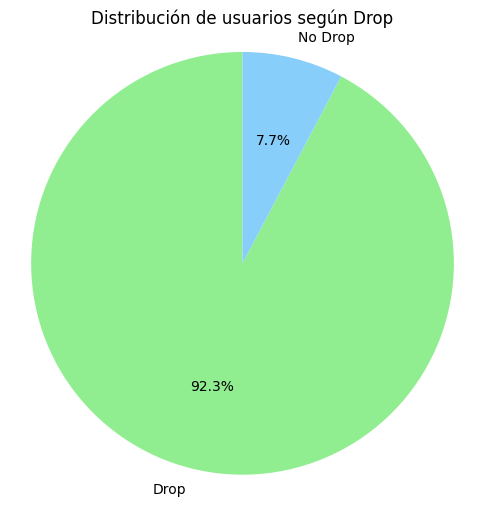

In [109]:
# Gráfico de distribución de usuarios con y sin drop
labels = ['Drop', 'No Drop']
sizes = [11991, 12996 - 11991]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightskyblue'],
    startangle=90
)
plt.title('Distribución de usuarios según Drop')
plt.axis('equal')
plt.show()

#### Comentarios sobre la Métrica de Drop

- **12.996 usuarios** participaron del onboarding (grupo observado).  
- **11.991 usuarios** (≈ 92.3%) hicieron *drop*, es decir:  
  - No volvieron a usar la app después de ver la home page, o  
  - Usaron la app solo el mismo día de registro y luego no regresaron.

En conclusión, **el 92.27 % de los usuarios nuevos no regresan a la aplicación luego del primer uso**.  
Este valor es muy elevado e indica una fuerte necesidad de **mejorar la experiencia inicial (onboarding)**, lo que justifica plenamente la implementación de un **A/B testing**.

### 3.3.2 Métrica 2: Activación

Mide el **porcentaje de usuarios en onboarding que realizan al menos una acción transaccional** dentro de los primeros 30 días desde su primer inicio de sesión.

In [110]:
# Paso 1: Crear una vista temporal para identificar usuarios activados
# Se realiza un JOIN entre Onboarding y Transactions, considerando transacciones dentro de los 30 días desde first_login_dt.
spark.sql(
    """
    CREATE OR REPLACE TEMP VIEW activacion_analysis AS
    SELECT
        o.user_id,
        o.first_login_dt,
        MIN(t.transaction_dt) AS primera_transaccion_dt,
        CASE
            WHEN MIN(t.transaction_dt) IS NOT NULL THEN 1
            ELSE 0
        END AS activado_flag
    FROM Onboarding o
    LEFT JOIN Transactions t
        ON o.user_id = t.user_id
        AND t.transaction_dt BETWEEN o.first_login_dt AND DATE_ADD(o.first_login_dt, 30)
    GROUP BY o.user_id, o.first_login_dt
    """
)

DataFrame[]

In [111]:
# Paso 2: Calcular el porcentaje de activación
spark.sql(
    """
    SELECT
        COUNT(*) AS total_usuarios,
        SUM(activado_flag) AS usuarios_activados,
        ROUND(SUM(activado_flag) * 100.0 / COUNT(*), 2) AS porcentaje_activacion
    FROM activacion_analysis
    """
).show()

+--------------+------------------+---------------------+
|total_usuarios|usuarios_activados|porcentaje_activacion|
+--------------+------------------+---------------------+
|         12996|              1524|                11.73|
+--------------+------------------+---------------------+



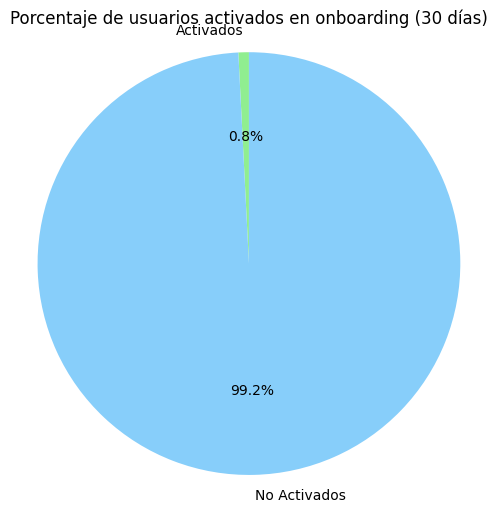

In [112]:
# Visualización del porcentaje de activación
labels = ['Activados', 'No Activados']
sizes = [104, 12996 - 104]  # 104 usuarios activados sobre 12.996

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%.1f%%',
    startangle=90,
    colors=['lightgreen', 'lightskyblue']
)
plt.title('Porcentaje de usuarios activados en onboarding (30 días)')
plt.axis('equal')
plt.show()

#### Comentarios sobre la Métrica de Activación

Menos del **1 % de los usuarios** en onboarding (**0,80 %**) realizaron al menos una transacción dentro de los primeros 30 días.  
Este bajo nivel de interacción transaccional inicial puede deberse a:

- **Problemas de adopción del producto**: muchos usuarios se registran pero no utilizan activamente los servicios, posiblemente por fallas en el diseño de la experiencia inicial.  
- **Onboarding poco efectivo**: si la etapa de onboarding busca guiar a los usuarios hacia productos financieros, el resultado sugiere que no lo logra. El flujo puede ser confuso, extenso o carecer de incentivos claros.

### 3.3.3 Métrica 3: Hábito

Esta métrica mide el porcentaje de usuarios en onboarding que alcanzan un nivel de uso habitual dentro de los primeros 30 días.  
Se consideran dos segmentos:

- **Individuals (segment = 1):** alcanzan hábito al realizar **5 transacciones en 5 días diferentes** durante el período de onboarding.  
- **Sellers (segment = 2):** alcanzan hábito al realizar **5 transacciones de cobro**, sin importar los días, durante el onboarding.

En la tabla `Transactions`, la columna `segment` identifica el tipo de usuario (1 = individual, 2 = seller), y la columna `type` especifica el tipo de transacción (`pago` o `cobro`).  
Todas las transacciones y usuarios ya están filtrados por país (Brasil).


In [113]:
# Creamos una vista temporal con los usuarios que pasaron por la etapa de onboarding
spark.sql("""
CREATE OR REPLACE TEMP VIEW onboarding_users AS
SELECT DISTINCT user_id, first_login_dt
FROM Onboarding
""")

DataFrame[]

In [114]:
# Creamos una vista con transacciones dentro del período de onboarding (30 días desde el primer login)
spark.sql("""
CREATE OR REPLACE TEMP VIEW transacciones_onboarding AS
SELECT t.user_id, t.transaction_dt, t.type, t.segment
FROM Transactions t
JOIN onboarding_users o ON t.user_id = o.user_id
WHERE DATEDIFF(t.transaction_dt, o.first_login_dt) BETWEEN 0 AND 30
""")

DataFrame[]

In [115]:
# Un individual forma hábito si tiene transacciones en 5 días diferentes dentro del onboarding
spark.sql("""
CREATE OR REPLACE TEMP VIEW individual_habito AS
SELECT user_id
FROM transacciones_onboarding
WHERE segment = 1
GROUP BY user_id
HAVING COUNT(DISTINCT transaction_dt) >= 5
""")

DataFrame[]

In [116]:
# Un seller forma hábito si hace 5 transacciones de tipo 'cobro' dentro del onboarding
spark.sql("""
CREATE OR REPLACE TEMP VIEW seller_habito AS
SELECT user_id
FROM transacciones_onboarding
WHERE segment = 2 AND type = 'cobro'
GROUP BY user_id
HAVING COUNT(*) >= 5
""")

DataFrame[]

In [117]:
# Se unifican los usuarios con hábito: individuales y sellers
spark.sql("""
CREATE OR REPLACE TEMP VIEW habito_total AS
SELECT user_id FROM individual_habito
UNION
SELECT user_id FROM seller_habito
""")

DataFrame[]

In [118]:
# Calculamos la métrica final: porcentaje de usuarios con hábito
spark.sql("""
SELECT
  COUNT(DISTINCT o.user_id) AS total_usuarios_onboarding,
  COUNT(DISTINCT h.user_id) AS usuarios_con_habito,
  ROUND(COUNT(DISTINCT h.user_id) * 100.0 / COUNT(DISTINCT o.user_id), 2) AS porcentaje_habito
FROM onboarding_users o
LEFT JOIN habito_total h ON o.user_id = h.user_id
""").show()

+-------------------------+-------------------+-----------------+
|total_usuarios_onboarding|usuarios_con_habito|porcentaje_habito|
+-------------------------+-------------------+-----------------+
|                    12996|                  0|             0.00|
+-------------------------+-------------------+-----------------+



**Otra estrategia para calcular Hábito**

Dado que, al usar *joins*, la métrica arrojó 0, a continuación se utiliza directamente la columna hábito de la tabla onboarding, que ya trae el valor booleano (1 si consolidó hábito, 0 si no), presumiblemente precalculado según la lógica de negocio de la consigna.

In [119]:
# Porcentaje de usuarios en onboarding que tienen hábito = 1
spark.sql("""
SELECT
  COUNT(*) AS total_usuarios,
  SUM(CASE WHEN habito = 1 THEN 1 ELSE 0 END) AS usuarios_con_habito,
  ROUND(SUM(CASE WHEN habito = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS porcentaje_habito
FROM Onboarding
""").show()

+--------------+-------------------+-----------------+
|total_usuarios|usuarios_con_habito|porcentaje_habito|
+--------------+-------------------+-----------------+
|         12996|               1531|            11.78|
+--------------+-------------------+-----------------+



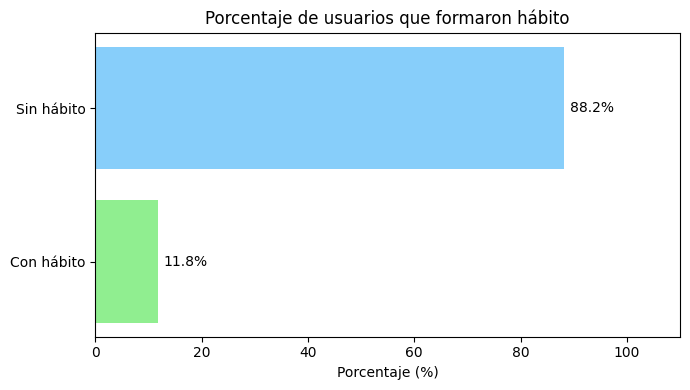

In [120]:
# Visualización de la métrica Setup mediante un gráfico de barras
# Se muestra la proporción de usuarios que realizaron acciones de setup vs. quienes no lo hicieron.
valores = [11.8, 100 - 11.78]
etiquetas = ['Con hábito', 'Sin hábito']

plt.figure(figsize=(7, 4))
bars = plt.barh(etiquetas, valores, color=['lightgreen', 'lightskyblue'])

# Se agrega texto con los porcentajes sobre las barras
for bar, valor in zip(bars, valores):
    plt.text(valor + 1, bar.get_y() + bar.get_height() / 2,
             f'{valor:.1f}%', va='center')

plt.xlabel('Porcentaje (%)')
plt.title('Porcentaje de usuarios que formaron hábito')
plt.xlim(0, 110)  # un poco más de 100 para que entre el texto
plt.tight_layout()
plt.show()

**Comentarios sobre métrica Hábito**

- De los 12.996 usuarios en proceso de onboarding, 1.531 usuarios (11.8%) formaron hábito (es decir, usaron activamente la aplicación más allá del registro inicial).

- Esto indica que, si bien hay una gran pérdida de usuarios iniciales (como evidenció la métrica drop), existe un grupo minoritario pero significativo que se logra consolidar como usuarios activos.

- La formación de hábito es uno de los objetivos centrales del onboarding, por lo tanto, una tasa inferior al 12% sugiere oportunidades de mejora importantes:

 -  Revisar incentivos transaccionales tempranos.

 - Acompañamiento del usuario durante los primeros días.

 - Mejora de la interfaz para facilitar acciones frecuentes.

### 3.3.4 Métrica 4: Setup

Mide el **porcentaje de usuarios en onboarding que realizaron al menos una acción de setup** (por ejemplo, agregar una tarjeta de crédito a la billetera digital, activar la llave PIX, activar rendimientos en cuenta, etc.).  
Esta métrica permite evaluar en qué medida los nuevos usuarios adoptan funcionalidades clave durante los primeros 30 días.

In [121]:
# Se calcula el porcentaje de usuarios con setup
spark.sql(
    """
    SELECT
        COUNT(*) AS total_usuarios,
        SUM(CASE WHEN setup = true THEN 1 ELSE 0 END) AS usuarios_con_setup,
        ROUND(SUM(CASE WHEN setup = true THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS porcentaje_setup
    FROM Onboarding
    """
).show()

+--------------+------------------+----------------+
|total_usuarios|usuarios_con_setup|porcentaje_setup|
+--------------+------------------+----------------+
|         12996|              5520|           42.47|
+--------------+------------------+----------------+



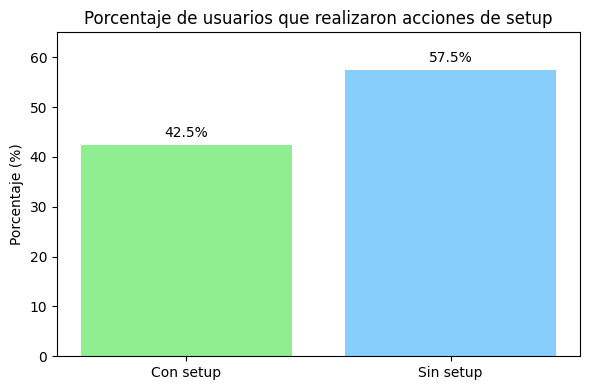

In [122]:
# Visualización de la proporción de usuarios que realizaron acciones de setup vs. los que no
etiquetas = ['Con setup', 'Sin setup']
valores = [42.47, 100 - 42.47]

plt.figure(figsize=(6, 4))
bars = plt.bar(etiquetas, valores, color=['lightgreen', 'lightskyblue'])

# Se agregan etiquetas porcentuales sobre las barras
for bar, valor in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width() / 2, valor + 1,
             f'{valor:.1f}%', ha='center', va='bottom')

plt.ylabel('Porcentaje (%)')
plt.title('Porcentaje de usuarios que realizaron acciones de setup')
plt.ylim(0, 65)
plt.tight_layout()
plt.show()

**Comentarios sobre métrica Setup**

- 42,5% de los usuarios en onboarding realizaron al menos una acción de setup.

- Esto significa que menos de la mitad de los nuevos usuarios configuran funcionalidades clave como agregar tarjetas, activar PIX, rendimientos, etc., durante los primeros 30 días.